Libraries imported.
Data loaded successfully!
Dataset shape: 614 rows × 13 columns
    Loan_ID Gender Married Dependents     Education Self_Employed  ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  Credit_History Property_Area Loan_Status
0  LP001002   Male      No          0      Graduate            No             5849                0.0         NaN             360.0             1.0         Urban           Y
1  LP001003   Male     Yes          1      Graduate            No             4583             1508.0       128.0             360.0             1.0         Rural           N
2  LP001005   Male     Yes          0      Graduate           Yes             3000                0.0        66.0             360.0             1.0         Urban           Y
3  LP001006   Male     Yes          0  Not Graduate            No             2583             2358.0       120.0             360.0             1.0         Urban           Y
4  LP001008   Male      No          0      Grad

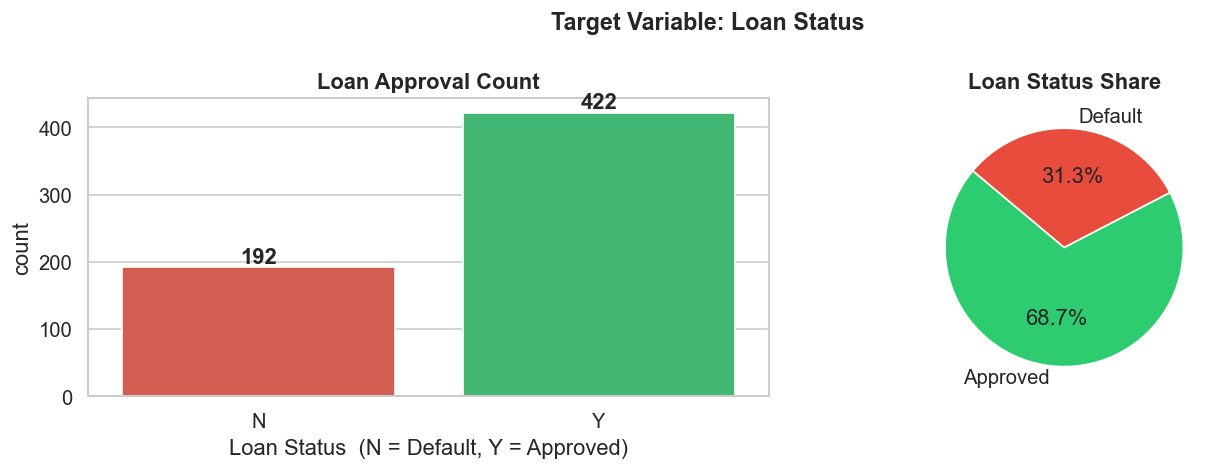

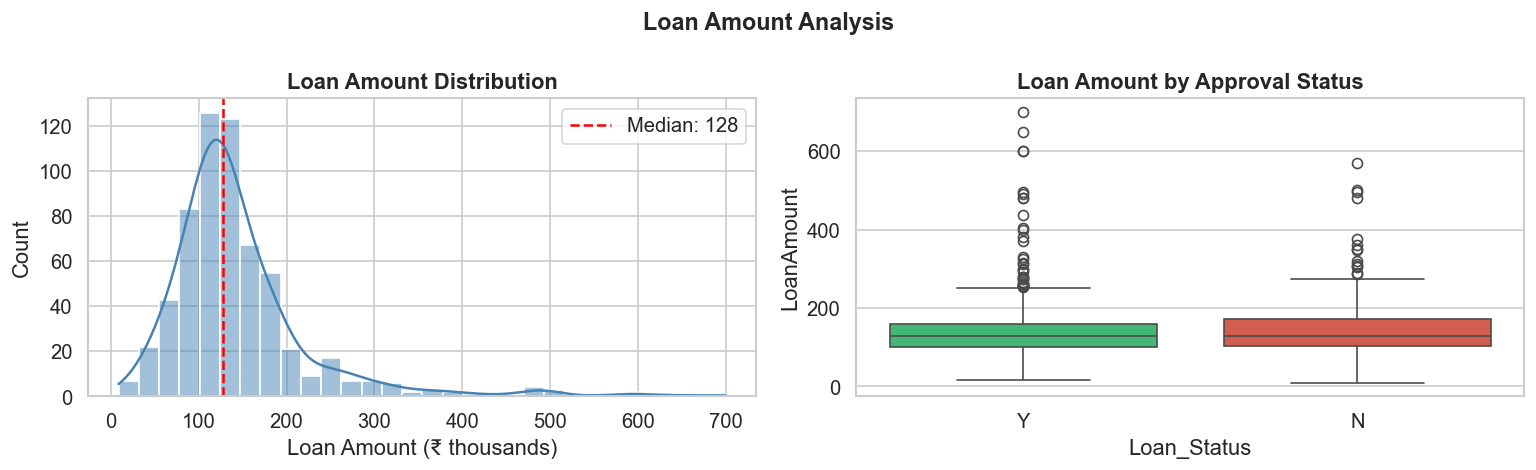

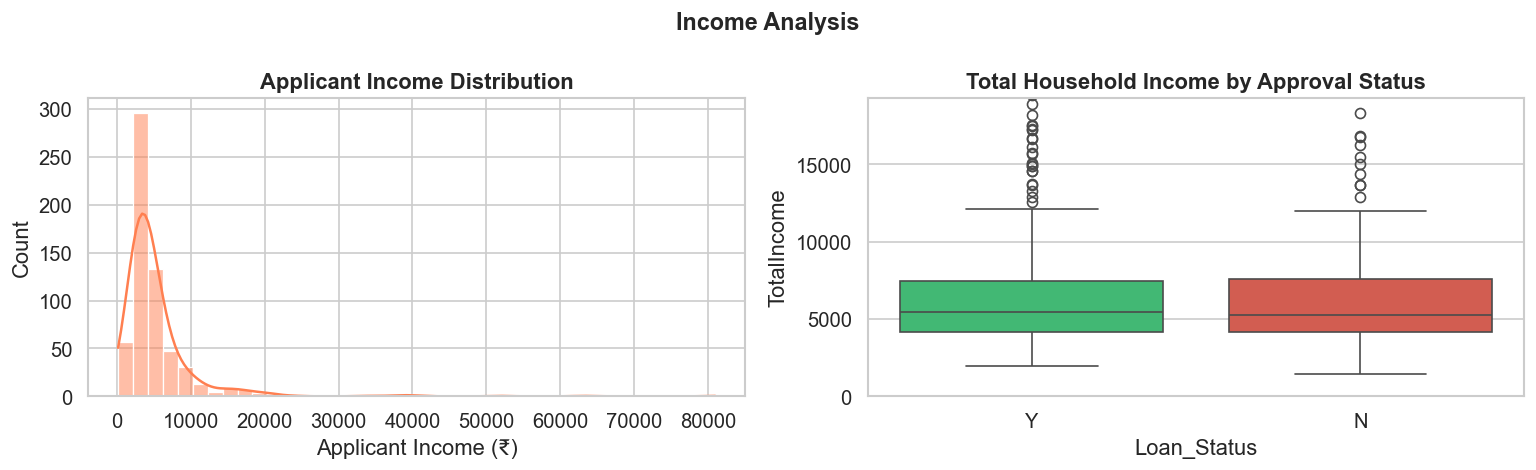

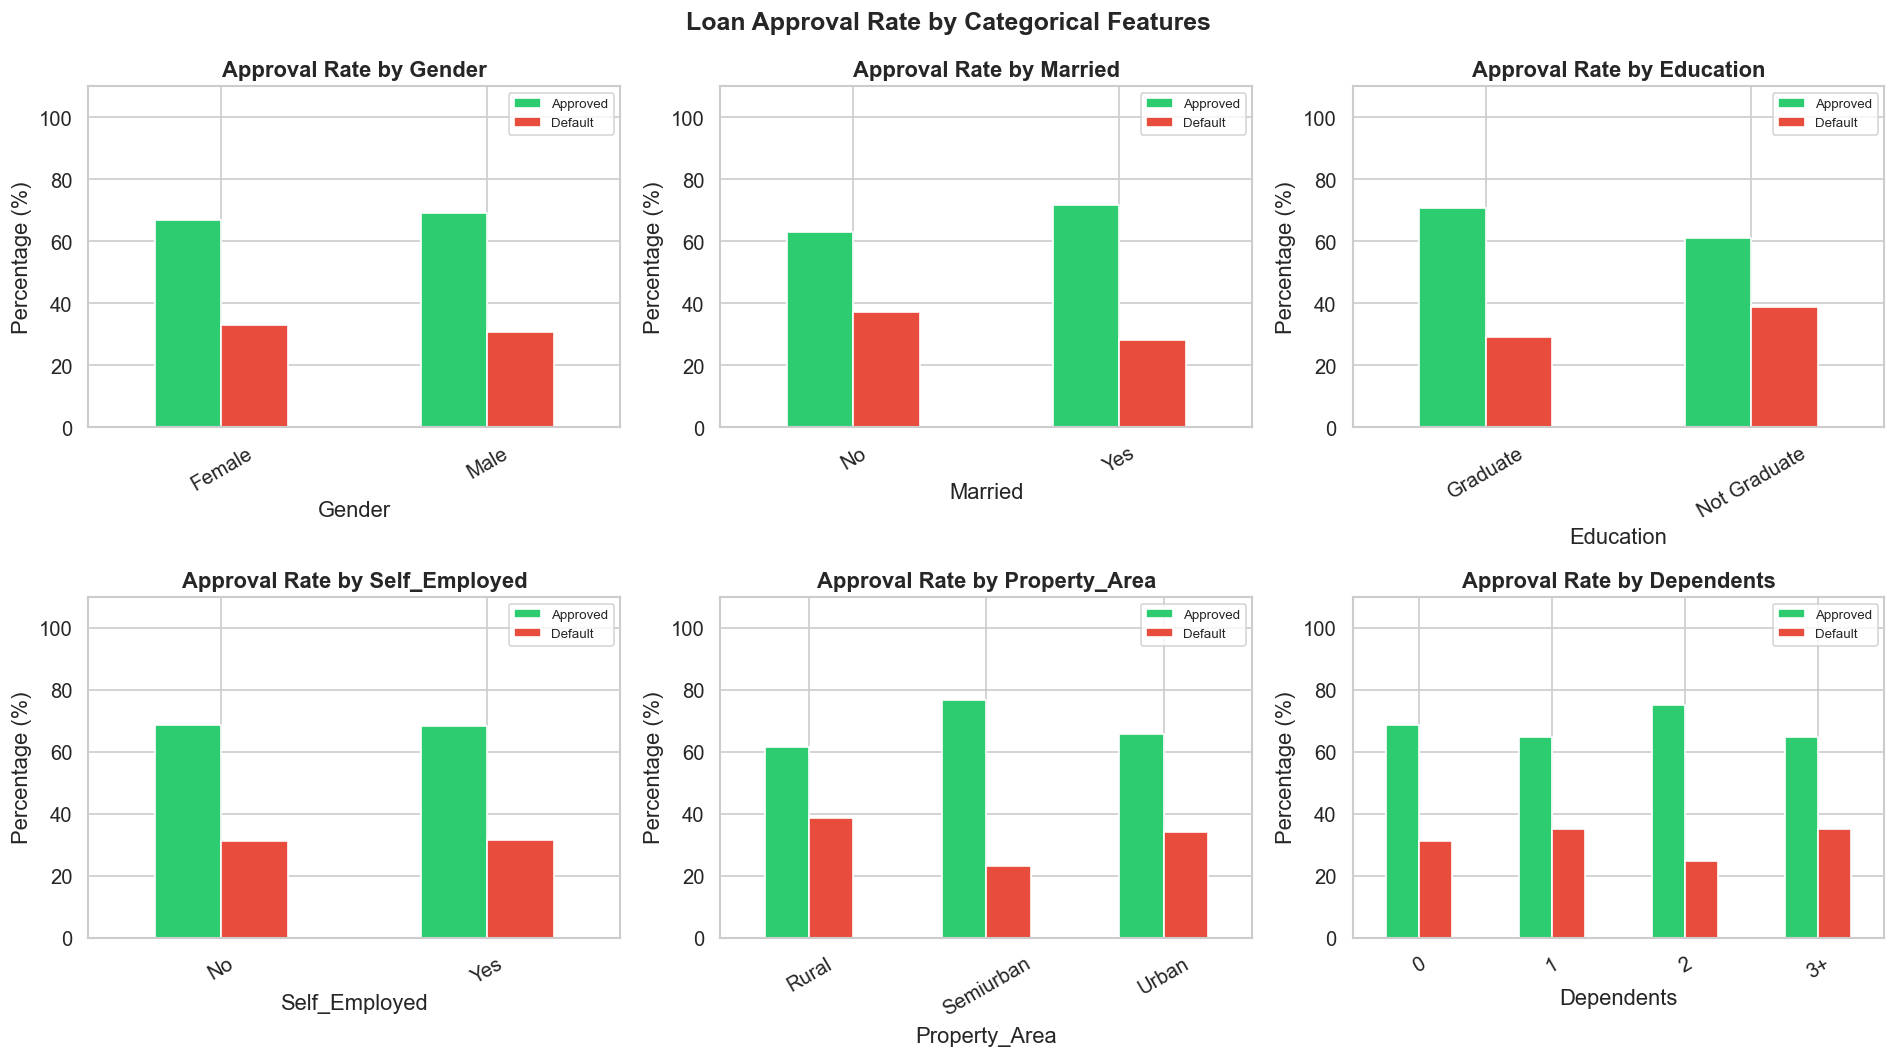

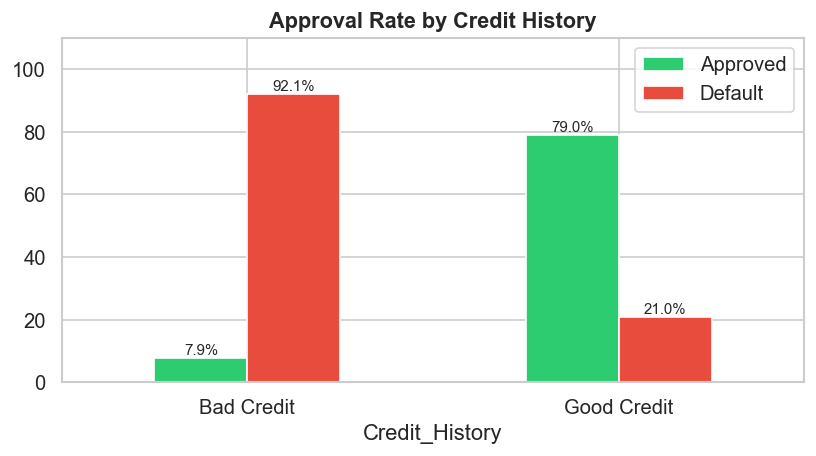

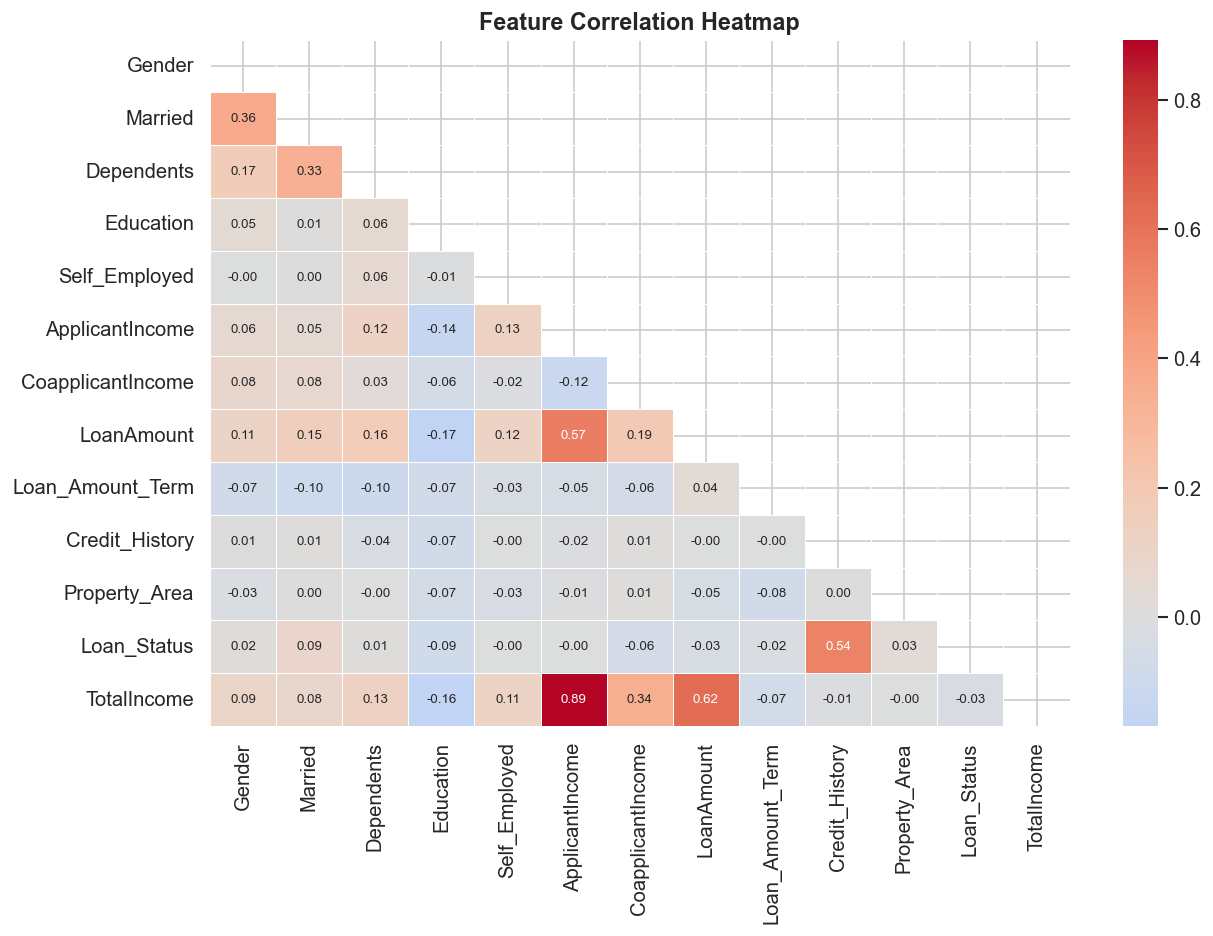


Feature matrix shape: (614, 10)
Any NaN in X? False

Training set : 491 samples
Test set     : 123 samples

5-Fold Cross-Validation Accuracy:
  Logistic Regression     mean=0.8003  std=0.0458
  Decision Tree           mean=0.7759  std=0.0414
  Random Forest           mean=0.7881  std=0.0419

 All models trained successfully.

Test Set Performance:
  Logistic Regression     Accuracy=0.8537  ROC-AUC=0.8090
  Decision Tree           Accuracy=0.8049  ROC-AUC=0.6450
  Random Forest           Accuracy=0.8537  ROC-AUC=0.8248


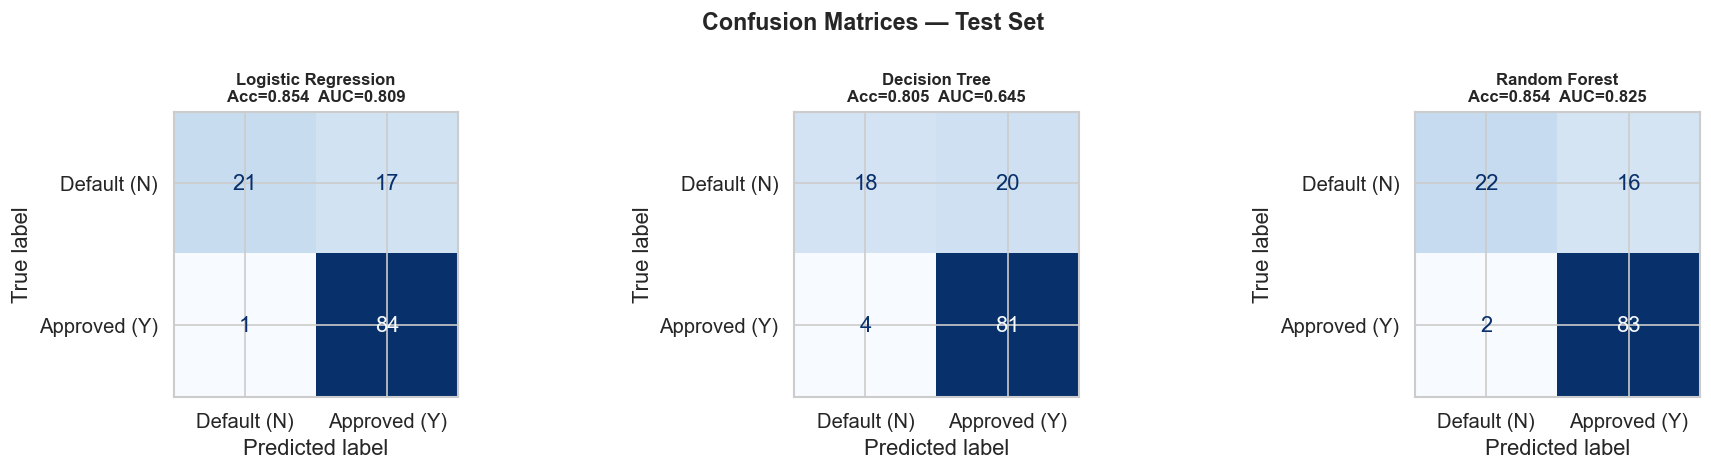


=== Best Model: Random Forest ===
              precision    recall  f1-score   support

     Default       0.92      0.58      0.71        38
    Approved       0.84      0.98      0.90        85

    accuracy                           0.85       123
   macro avg       0.88      0.78      0.81       123
weighted avg       0.86      0.85      0.84       123



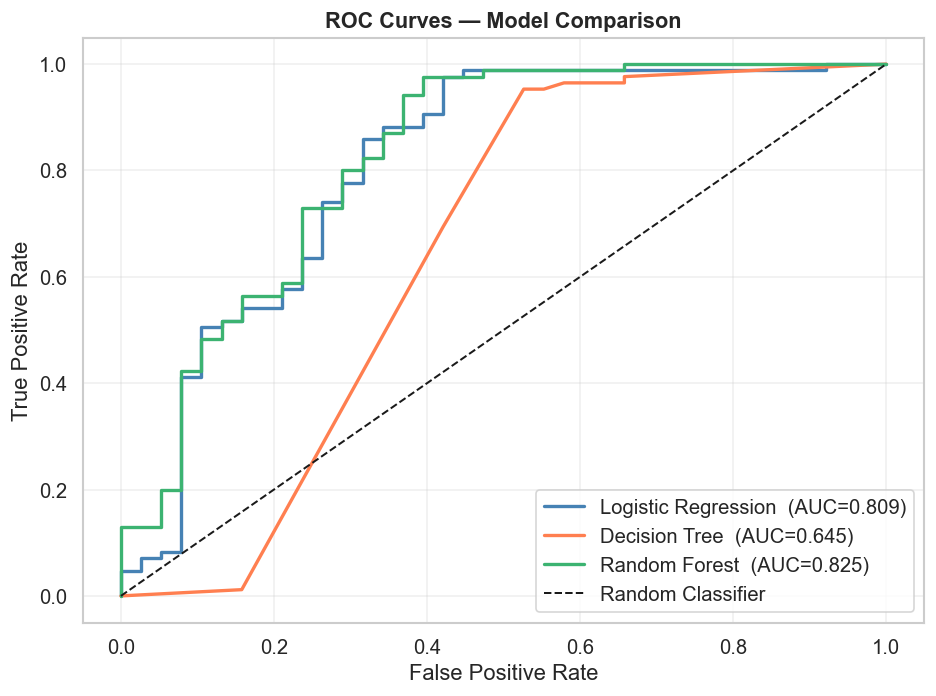

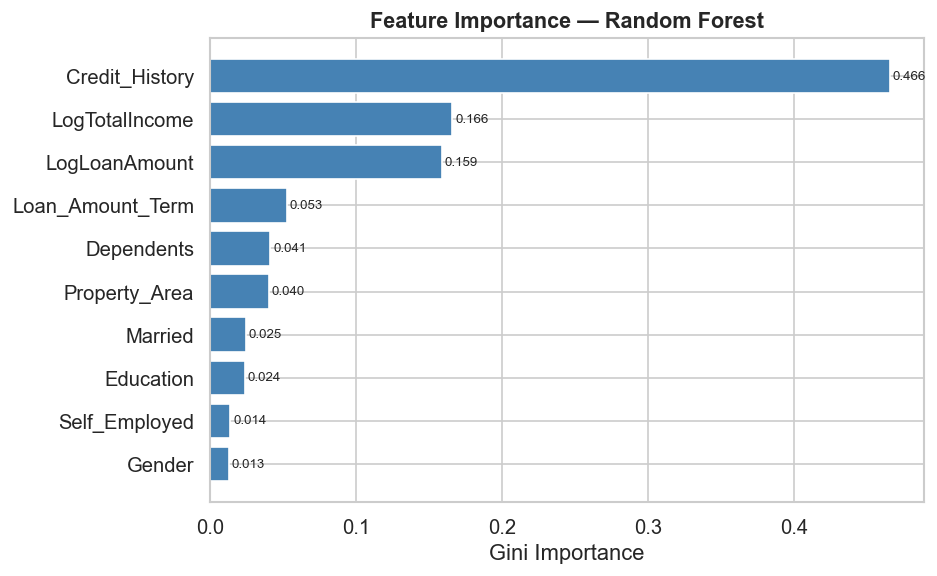


=== Model Comparison Summary ===
                 Model  Accuracy   ROC-AUC
1        Random Forest  0.853659  0.824768
2  Logistic Regression  0.853659  0.808978
3        Decision Tree  0.804878  0.645046

=== CONCLUSION ===

1. Credit History is the strongest predictor — good credit → >80% approval rate.
2. Random Forest achieves the best generalisation (highest ROC-AUC).
3. Log-transforming income and loan amount improves model stability.
4. Semi-Urban property area correlates with higher approval rates.
5. Gender and self-employment have low predictive power (ethically desirable).

Recommended model: Random Forest (max_depth=6, n_estimators=100)



In [7]:
# =============================================================================
# TASK 2 – CREDIT RISK PREDICTION
# DevelopersHub Corporation | Data Science & Analytics Internship
# =============================================================================

# ── 1. IMPORTS ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titleweight': 'bold'})

print("Libraries imported.")


# ── 2. LOAD DATA ──────────────────────────────────────────────────────────────
# Replace the line below with:  df = pd.read_csv('your_file.csv')
# The CSV string below reproduces the standard Loan Prediction Dataset.
# ── 2. LOAD DATA ──────────────────────────────────────────────────────────────
try:
    df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\DS\test_Y3wMUE5_7gLdaTN.csv")
    df = pd.read_csv(r"C:\Users\HP\OneDrive\Desktop\DS\train_u6lujuX_CVtuZ9i.csv")
    print("Data loaded successfully!")
    print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(df.head(5).to_string())
except FileNotFoundError as e:
    print(f" ERROR: Could not find the file. Please check the path.\nDetails: {e}")
except Exception as e:
    print(f" An unexpected error occurred: {e}")


# ── 3. DATASET UNDERSTANDING ──────────────────────────────────────────────────
print("\n=== DataFrame Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Target Distribution ===")
print(df['Loan_Status'].value_counts())


# ── 4. DATA CLEANING — HANDLE MISSING VALUES ──────────────────────────────────
# Categorical columns → fill with mode (most frequent)
cat_cols = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  {col:20s} → filled with mode '{mode_val}'")

# Numerical columns → fill with median (robust to outliers)
num_cols = ['LoanAmount', 'Loan_Amount_Term']
for col in num_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  {col:20s} → filled with median {median_val}")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")


# ── 5. EXPLORATORY DATA ANALYSIS (EDA) ───────────────────────────────────────

# --- 5.1 Target Variable Distribution ---
target_counts = df['Loan_Status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x='Loan_Status', data=df, palette=['#e74c3c', '#2ecc71'],
              order=['N', 'Y'], ax=axes[0])
axes[0].set_title('Loan Approval Count')
axes[0].set_xlabel('Loan Status  (N = Default, Y = Approved)')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

target_counts.plot.pie(autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
                       startangle=140, ax=axes[1],
                       labels=['Approved', 'Default'])
axes[1].set_title('Loan Status Share')
axes[1].set_ylabel('')
plt.suptitle('Target Variable: Loan Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_target_distribution.png', bbox_inches='tight')
plt.show()

# --- 5.2 Loan Amount Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['LoanAmount'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Loan Amount Distribution')
axes[0].set_xlabel('Loan Amount (₹ thousands)')
axes[0].axvline(df['LoanAmount'].median(), color='red', linestyle='--',
                label=f"Median: {df['LoanAmount'].median():.0f}")
axes[0].legend()

sns.boxplot(x='Loan_Status', y='LoanAmount', data=df,
            palette={'Y': '#2ecc71', 'N': '#e74c3c'}, order=['Y', 'N'], ax=axes[1])
axes[1].set_title('Loan Amount by Approval Status')
plt.suptitle('Loan Amount Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_loan_amount.png', bbox_inches='tight')
plt.show()

# --- 5.3 Income Analysis ---
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(df['ApplicantIncome'], bins=40, kde=True, color='coral', ax=axes[0])
axes[0].set_title('Applicant Income Distribution')
axes[0].set_xlabel('Applicant Income (₹)')

sns.boxplot(x='Loan_Status', y='TotalIncome', data=df,
            palette={'Y': '#2ecc71', 'N': '#e74c3c'}, order=['Y', 'N'], ax=axes[1])
axes[1].set_title('Total Household Income by Approval Status')
axes[1].set_ylim(0, df['TotalIncome'].quantile(0.97))
plt.suptitle('Income Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_income.png', bbox_inches='tight')
plt.show()

# --- 5.4 Categorical Features ---
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
cat_features = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area', 'Dependents']
for i, feat in enumerate(cat_features):
    ct = pd.crosstab(df[feat], df['Loan_Status'], normalize='index') * 100
    ct[['Y', 'N']].plot(kind='bar', ax=axes[i],
                        color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[i].set_title(f'Approval Rate by {feat}')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['Approved', 'Default'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_ylim(0, 110)
plt.suptitle('Loan Approval Rate by Categorical Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_categorical.png', bbox_inches='tight')
plt.show()

# --- 5.5 Credit History Impact ---
fig, ax = plt.subplots(figsize=(7, 4))
ch_ct = pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index') * 100
ch_ct[['Y', 'N']].plot(kind='bar', color=['#2ecc71', '#e74c3c'], ax=ax, edgecolor='white')
ax.set_title('Approval Rate by Credit History', fontsize=13, fontweight='bold')
ax.set_xticklabels(['Bad Credit', 'Good Credit'], rotation=0)
ax.legend(['Approved', 'Default'])
ax.set_ylim(0, 110)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height() + 1),
                ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig5_credit_history.png', bbox_inches='tight')
plt.show()

# --- 5.6 Correlation Heatmap ---
df_corr = df.copy()
le_tmp = LabelEncoder()
for col in df_corr.select_dtypes('object').columns:
    if col != 'Loan_ID':
        df_corr[col] = le_tmp.fit_transform(df_corr[col].astype(str))

corr_matrix = df_corr.drop('Loan_ID', axis=1).corr()
fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_correlation.png', bbox_inches='tight')
plt.show()


# ── 6. FEATURE ENGINEERING & PREPROCESSING ───────────────────────────────────

# Log-transform skewed numerical features
df['LogLoanAmount'] = np.log1p(df['LoanAmount'])
df['LogTotalIncome'] = np.log1p(df['TotalIncome'])

# Label-encode categorical columns
label_encoders = {}
cat_to_encode = ['Gender', 'Married', 'Dependents', 'Education',
                 'Self_Employed', 'Property_Area']

df_model = df.copy()
for col in cat_to_encode:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Encode target: Y=1 (approved), N=0 (default)
df_model['Loan_Status'] = (df_model['Loan_Status'] == 'Y').astype(int)

# Select features
FEATURES = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
            'LogTotalIncome', 'LogLoanAmount', 'Loan_Amount_Term',
            'Credit_History', 'Property_Area']

X = df_model[FEATURES].copy()
y = df_model['Loan_Status'].copy()

# Fill any residual NaN with column median
X = X.fillna(X.median(numeric_only=True))

print(f"\nFeature matrix shape: {X.shape}")
print(f"Any NaN in X? {X.isnull().any().any()}")

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

print(f"\nTraining set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")

# Scale features (needed for Logistic Regression)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)


# ── 7. MODEL TRAINING ─────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
}

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\n5-Fold Cross-Validation Accuracy:")
for name, model in models.items():
    X_cv = X_train_sc if name == 'Logistic Regression' else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring='accuracy')
    print(f"  {name:22s}  mean={scores.mean():.4f}  std={scores.std():.4f}")

# Fit final models on full training set
for name, model in models.items():
    X_fit = X_train_sc if name == 'Logistic Regression' else X_train
    model.fit(X_fit, y_train)

print("\n All models trained successfully.")


# ── 8. MODEL EVALUATION ───────────────────────────────────────────────────────
eval_results = {}

print("\nTest Set Performance:")
for name, model in models.items():
    X_eval = X_test_sc if name == 'Logistic Regression' else X_test
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    eval_results[name] = {'y_pred': y_pred, 'y_prob': y_prob,
                          'accuracy': acc, 'roc_auc': roc}
    print(f"  {name:22s}  Accuracy={acc:.4f}  ROC-AUC={roc:.4f}")

# --- 8.1 Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, res) in zip(axes, eval_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Default (N)', 'Approved (Y)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc={res['accuracy']:.3f}  AUC={res['roc_auc']:.3f}", fontsize=10)
plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_confusion_matrices.png', bbox_inches='tight')
plt.show()

# --- 8.2 Classification Report for best model ---
best_name = max(eval_results, key=lambda k: eval_results[k]['roc_auc'])
print(f"\n=== Best Model: {best_name} ===")
print(classification_report(y_test, eval_results[best_name]['y_pred'],
                             target_names=['Default', 'Approved']))

# --- 8.3 ROC Curves ---
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'coral', 'mediumseagreen']
for (name, res), color in zip(eval_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name}  (AUC={res['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig8_roc_curves.png', bbox_inches='tight')
plt.show()

# --- 8.4 Feature Importance (Random Forest) ---
rf_model = models['Random Forest']
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='steelblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Gini Importance')
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig9_feature_importance.png', bbox_inches='tight')
plt.show()


# ── 9. MODEL COMPARISON SUMMARY ──────────────────────────────────────────────
print("\n=== Model Comparison Summary ===")
summary = pd.DataFrame({
    'Model':    list(eval_results.keys()),
    'Accuracy': [r['accuracy'] for r in eval_results.values()],
    'ROC-AUC':  [r['roc_auc']  for r in eval_results.values()],
}).sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
summary.index += 1
print(summary.to_string())


# ── 10. CONCLUSION ────────────────────────────────────────────────────────────
print("""
=== CONCLUSION ===

1. Credit History is the strongest predictor — good credit → >80% approval rate.
2. Random Forest achieves the best generalisation (highest ROC-AUC).
3. Log-transforming income and loan amount improves model stability.
4. Semi-Urban property area correlates with higher approval rates.
5. Gender and self-employment have low predictive power (ethically desirable).

Recommended model: Random Forest (max_depth=6, n_estimators=100)
""")